In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10011
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  350.9300698344639
RUN  2 , total integrated cost =  169.24355196132038
RUN  3 , total integrated cost =  152.34446749232117
RUN  4 , total integrated cost =  148.76652290129692
RUN  5 , total integrated cost =  143.11014064411032
RUN  6 , total integrated cost =  140.20414477094178
RUN  7 , total integrated cost =  136.32955644597527
RUN  8 , total integrated cost =  132.2078349004598
RUN  9 , total integrated cost =  127.20747354170125
RUN  10 , total integrated cost =  122.5231994418676
RUN  11 , total integrated cost =  119.13189611773143
RUN  12 , total integrated cost =  112.63587536450947
RUN  13 , total integrated cost =  111.39023756962754
RUN  14 , total integrated cost =  110.8809689535823
RUN  15 , total integrated cost =  110.37904753263565
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  511 , total integrated cost =  102.54407626269236
Improved over  511  iterations in  45.31208012625575  seconds by  98.26267342611206  percent.
Problem in initial value trasfer:  Vmean_exc -63.21502323247917 -63.209225218008676
weight =  575.5970207501689
set cost params:  1.0 0.0 575.5970207501689
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.925440882826
Gradient descend method:  None
RUN  1 , total integrated cost =  5882.4279311455975
RUN  2 , total integrated cost =  5882.419100593967
RUN  3 , total integrated cost =  5882.179709705041
RUN  4 , total integrated cost =  5881.9085723726075
RUN  5 , total integrated cost =  5881.899676568918
RUN  6 , total integrated cost =  5881.814199102528
RUN  7 , total integrated cost =  5881.693377044825
RUN  8 , total integrated cost =  5881.686170292699
RUN  9 , total integrated cost =  5880.2797438401885
RUN  10 , total integrated cost =  5879.071485744191
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  35 , total integrated cost =  5875.604366178881
Improved over  35  iterations in  2.4166122879832983  seconds by  0.34466302038076435  percent.
Problem in initial value trasfer:  Vmean_exc -64.40525689011164 -64.41798649650185
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  9213.393746532889
RUN  2 , total integrated cost =  9176.434486437742
RUN  3 , total integrated cost =  9176.30000090888
RUN  4 , total integrated cost =  9176.290984856932
RUN  5 , total integrated cost =  9176.282136626325
RUN  6 , total integrated cost =  9176.272963579868
RUN  7 , total integrated cost =  9176.266370477239
RUN  8 , total integrated cost =  9176.257280528911
RUN  9 , total integrated cost =  9176.247706280026
RUN  10 , total integrated cost =  9176.240815470856
RUN  11 , to

...

RUN  1 , total integrated cost =  17906.531722226882
Control only changes marginally.
RUN  1 , total integrated cost =  17906.531722226882
Improved over  1  iterations in  0.19901868887245655  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.689089409245945 -56.689198261636506
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14446.643021512598
Gradient descend method:  None
RUN  1 , total integrated cost =  13534.163832076661
RUN  2 , total integrated cost =  13484.259635589233
RUN  3 , total integrated cost =  13474.251295797352
RUN  4 , total integrated cost =  13469.719790652485
RUN  5 , total integrated cost =  13467.743474725998
RUN  6 , total integrated cost =  13466.457023343584
RUN  7 , total integrated cost =  13465.71354844963
RUN  8 , total integrated cost =  13465.414154088128
RUN  9 , total integrated cost =  13465.293775384049
RUN  10 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1362 , total integrated cost =  13448.497630245867
Improved over  1362  iterations in  87.60353410802782  seconds by  6.909185682655732  percent.
Problem in initial value trasfer:  Vmean_exc -56.67164716306421 -56.67182442511156
weight =  10.742198436368007
set cost params:  1.0 0.0 10.742198436368007
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13456.556735621538
Gradient descend method:  None
RUN  1 , total integrated cost =  13456.556735621538
Control only changes marginally.
RUN  1 , total integrated cost =  13456.556735621538
Improved over  1  iterations in  0.17634312622249126  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67164716306421 -56.67182442511156
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  106 , total integrated cost =  9084.89283594682
Improved over  106  iterations in  6.720356138423085  seconds by  9.332121961274936  percent.
Problem in initial value trasfer:  Vmean_exc -56.64438247109281 -56.64455896568848
weight =  11.029264405778761
set cost params:  1.0 0.0 11.029264405778761
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9096.94122309752
Gradient descend method:  None
RUN  1 , total integrated cost =  9096.94122309752
Control only changes marginally.
RUN  1 , total integrated cost =  9096.94122309752
Improved over  1  iterations in  0.1778927855193615  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64438247109281 -56.64455896568848


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


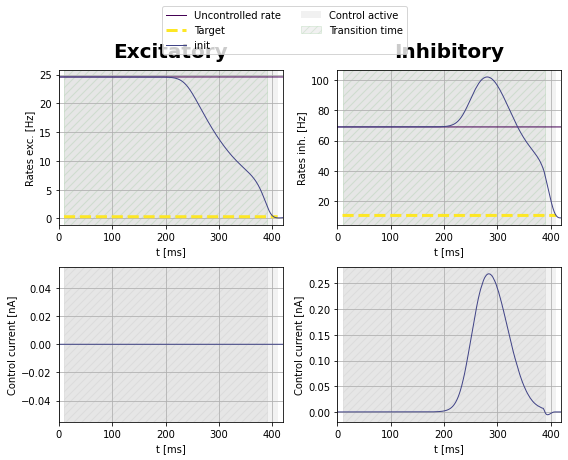

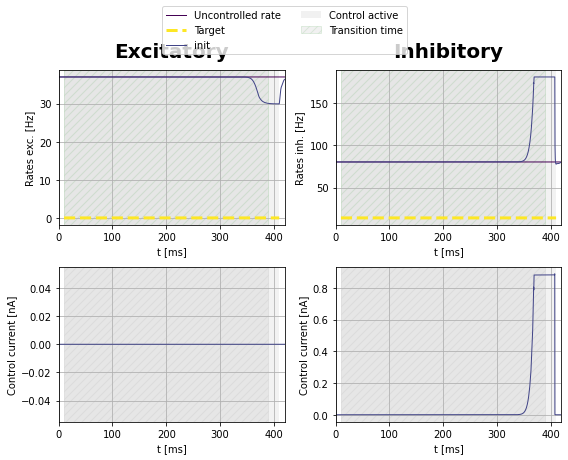

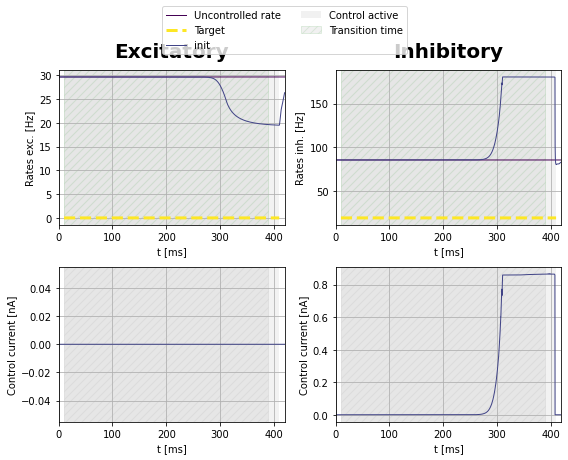

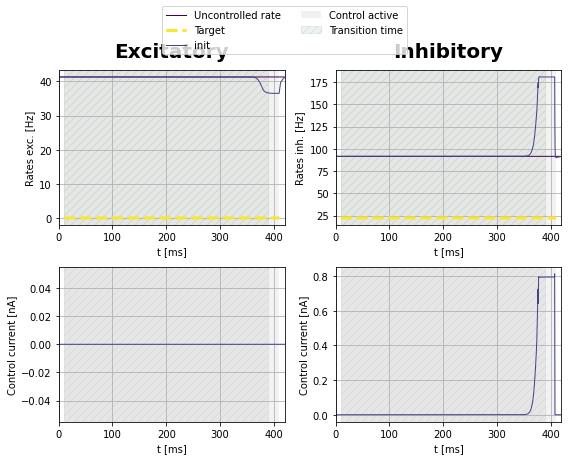

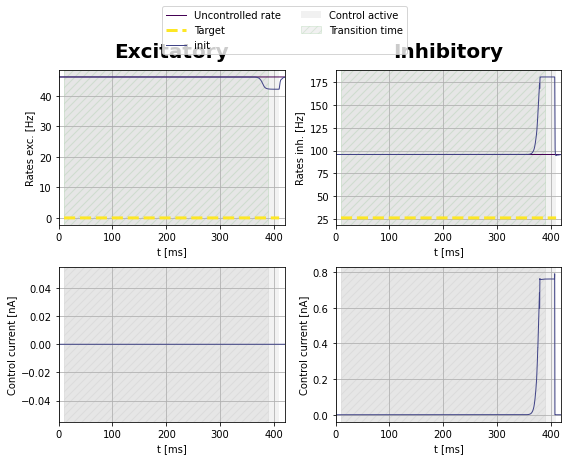

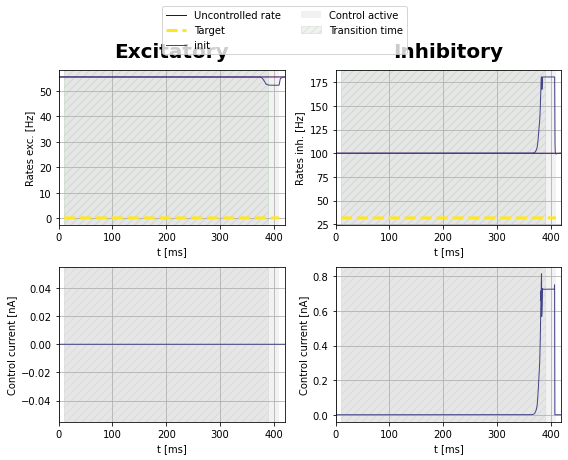

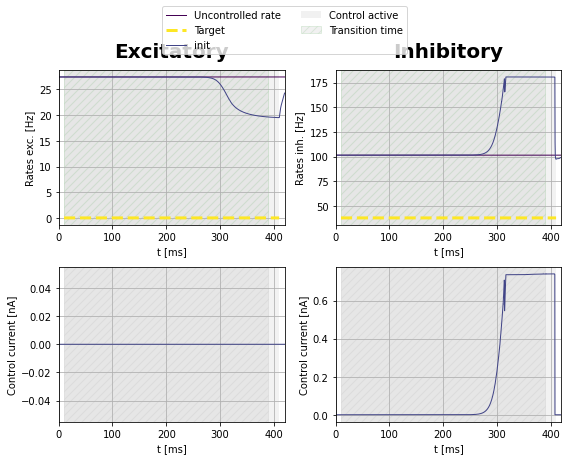

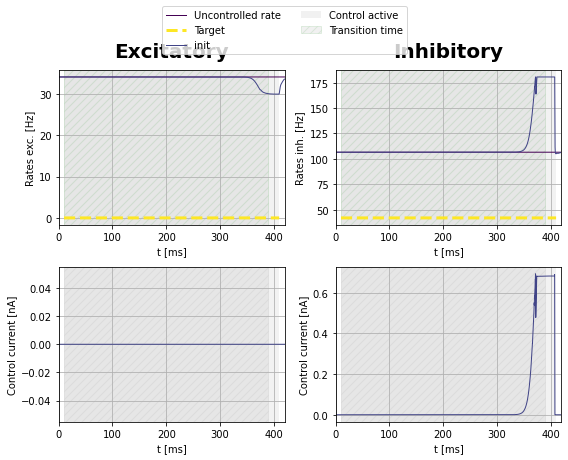

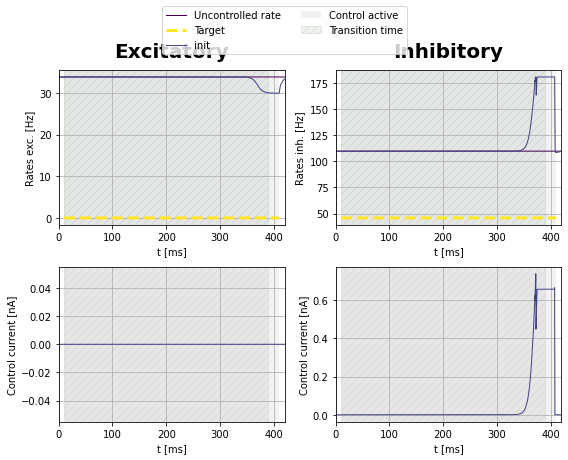

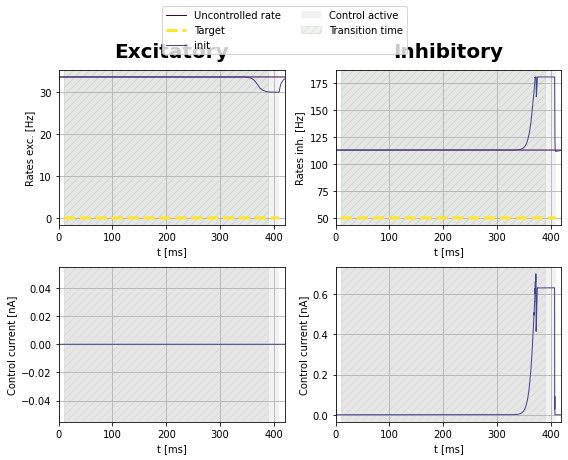

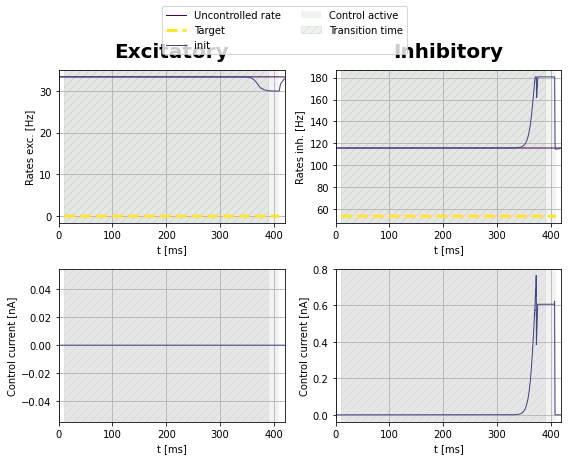

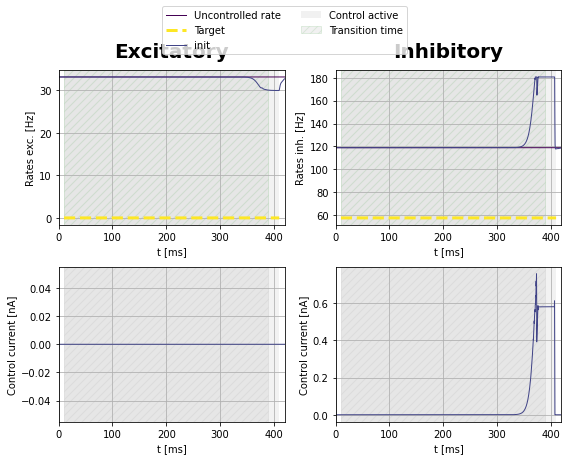

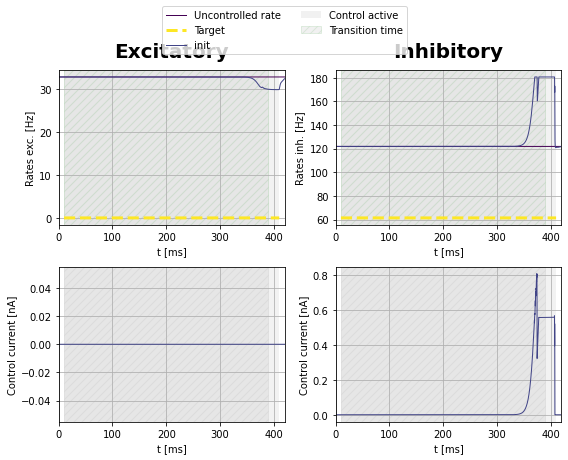

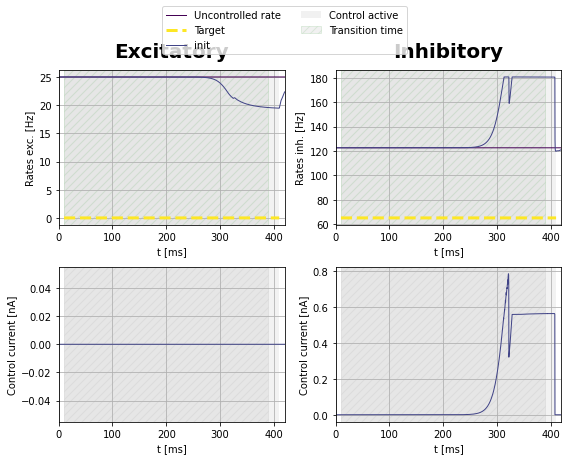

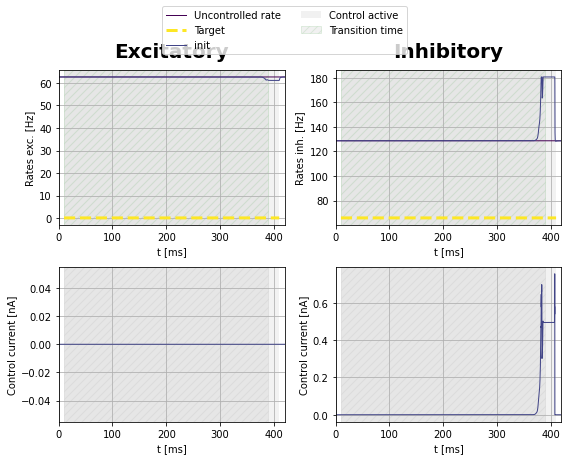

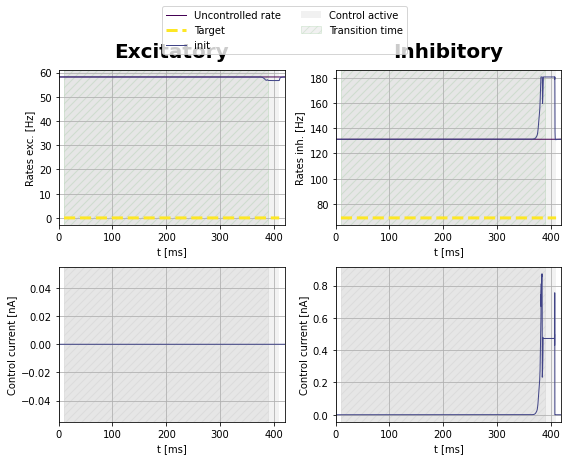

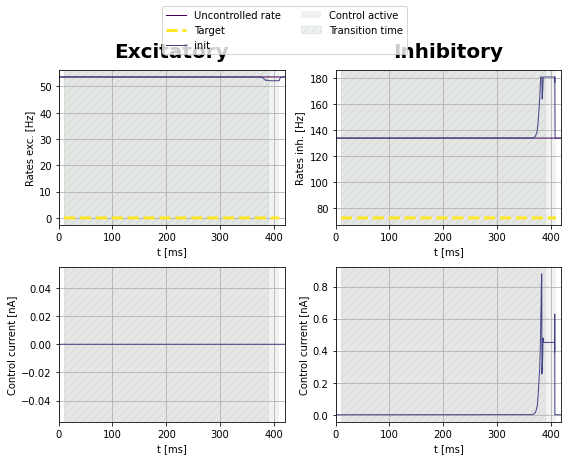

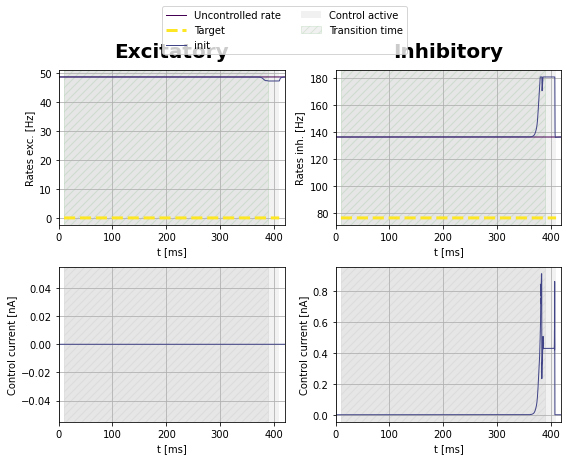

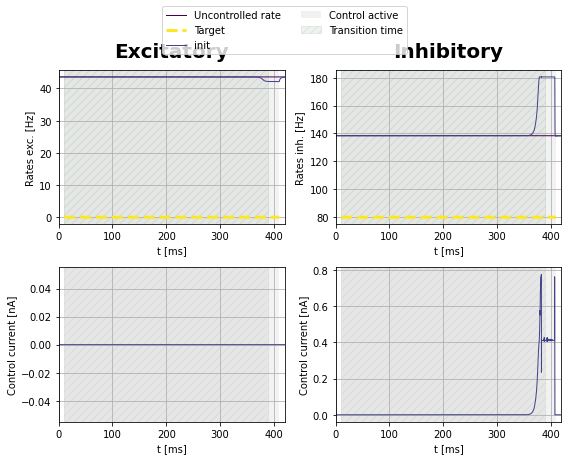

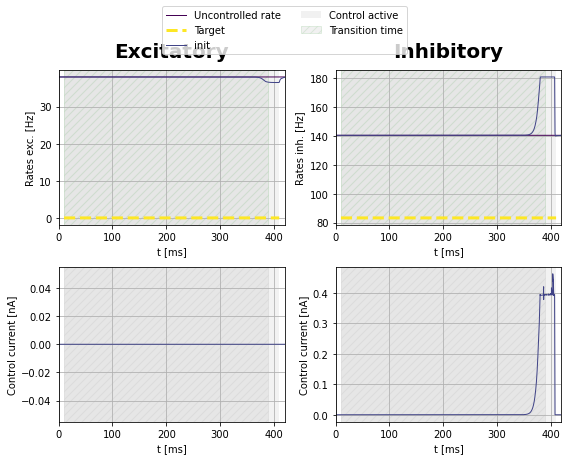

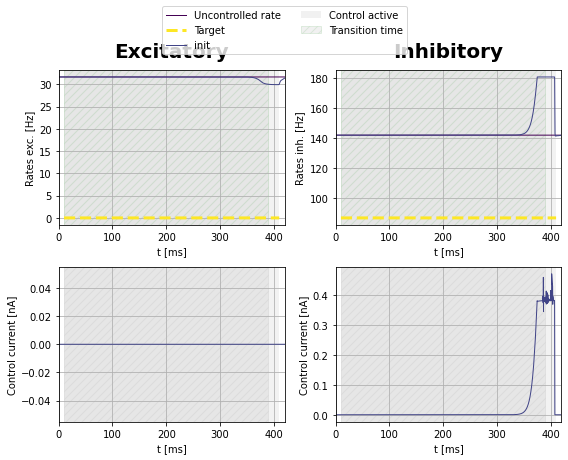

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  45 , total integrated cost =  9183.70718482672
Improved over  45  iterations in  2.8663530722260475  seconds by  32.84206629574497  percent.
Problem in initial value trasfer:  Vmean_exc -56.64463995006253 -56.64509542812589
weight =  14.762235811841094
set cost params:  1.0 0.0 14.762235811841094
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9311.534207960205
Gradient descend method:  None
RUN  1 , total integrated cost =  9311.534207960205
Control only changes marginally.
RUN  1 , total integrated cost =  9311.534207960205
Improved over  1  iterations in  0.1784938219934702  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64463995006253 -56.64509542812589
-------  14 0.4250000000000001 0.4500000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8894.677193766285
Gradient descend method:  N

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  233 , total integrated cost =  4356.626703029595
Improved over  233  iterations in  14.53158270008862  seconds by  51.01984469899731  percent.
Problem in initial value trasfer:  Vmean_exc -56.627750536365134 -56.62774156923909
weight =  20.19033568926358
set cost params:  1.0 0.0 20.19033568926358
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4707.954548041071
Gradient descend method:  None
RUN  1 , total integrated cost =  4707.954548041071
Control only changes marginally.
RUN  1 , total integrated cost =  4707.954548041071
Improved over  1  iterations in  0.1788334995508194  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627750536365134 -56.62774156923909
-------  21 0.47500000000000014 0.4750000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17187.21707733315
Gradient descend method:

...

Control only changes marginally.
RUN  136 , total integrated cost =  17899.470376238667
Improved over  136  iterations in  8.898320108652115  seconds by  6.340024308087976  percent.
Problem in initial value trasfer:  Vmean_exc -56.68908594159816 -56.68919467123838
weight =  10.615944571497153
set cost params:  1.0 0.0 10.615944571497153
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17907.24782000764
Gradient descend method:  None
RUN  1 , total integrated cost =  17907.24782000764
Control only changes marginally.
RUN  1 , total integrated cost =  17907.24782000764
Improved over  1  iterations in  0.17777303606271744  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68908594159816 -56.68919467123838
-------  133 0.47500000000000014 0.8750000000000006
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14553.579370871455
Gradient descend met

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  243 , total integrated cost =  13462.111572442649
Improved over  243  iterations in  15.669797468930483  seconds by  7.499651945509328  percent.
Problem in initial value trasfer:  Vmean_exc -56.67140530400356 -56.67154426135472
weight =  10.731335083483721
set cost params:  1.0 0.0 10.731335083483721
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13471.792286655203
Gradient descend method:  None
RUN  1 , total integrated cost =  13471.792286655203
Control only changes marginally.
RUN  1 , total integrated cost =  13471.792286655203
Improved over  1  iterations in  0.17645997554063797  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67140530400356 -56.67154426135472
-------  140 0.4500000000000001 0.9000000000000006
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10122.679174051797
Gradient descend 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  119 , total integrated cost =  9088.750633211486
Improved over  119  iterations in  7.550316093489528  seconds by  10.213981131503743  percent.
Problem in initial value trasfer:  Vmean_exc -56.64427941382026 -56.64444776887397
weight =  11.024582940990804
set cost params:  1.0 0.0 11.024582940990804
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9101.62545815714
Gradient descend method:  None
RUN  1 , total integrated cost =  9101.62545815714
Control only changes marginally.
RUN  1 , total integrated cost =  9101.62545815714
Improved over  1  iterations in  0.1776963397860527  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64427941382026 -56.64444776887397
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  577.222659827514
set cost params:  1.0 0.0 577.222659827514
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5892.183326109504
Gradient descend method:  None
RUN  1 , total integrated cost =  5892.183314724976
RUN  2 , total integrated cost =  5892.183314122733
RUN  3 , total integrated cost =  5892.1833140267445
RUN  4 , total integrated cost =  5892.183314011596
RUN  5 , total integrated cost =  5892.1833140084755
RUN  6 , total integrated cost =  5892.183314007665
RUN  7 , total integrated cost =  5892.183314007466
RUN  8 , total integrated cost =  5892.183

ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  5892.183314007377
RUN  10 , total integrated cost =  5892.183314007375
RUN  11 , total integrated cost =  5892.183314007375
Control only changes marginally.
RUN  11 , total integrated cost =  5892.183314007375
Improved over  11  iterations in  0.853637907654047  seconds by  2.0539296485821978e-07  percent.
Problem in initial value trasfer:  Vmean_exc -64.40359332921247 -64.41637688080378
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
no convergence
weight =  11.54608937386685
set cost params:  1.0 0.0 11.54608937386685
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27289.36893802301
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  27289.36893802301
Control only changes marginally.
RUN  1 , total integrated cost =  27289.36893802301
Improved over  1  iterations in  0.30412099324166775  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70355704116629 -56.70363259268394
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
no convergence
weight =  9.9986567940

...

RUN  1 , total integrated cost =  32306.47260059233
RUN  2 , total integrated cost =  32306.47260059233
Control only changes marginally.
RUN  2 , total integrated cost =  32306.47260059233
Improved over  2  iterations in  0.31605441495776176  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.703840353909655 -56.70384166885556
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[False, False], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, False], [True, True], [True, True], [Tru

ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  5892.198662190516
Gradient descend method:  None
RUN  1 , total integrated cost =  5892.198662190516
Control only changes marginally.
RUN  1 , total integrated cost =  5892.198662190516
Improved over  1  iterations in  0.18077659234404564  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.40358815387454 -64.41637187299277
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-----

ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  32299.87061411638
Gradient descend method:  None
RUN  1 , total integrated cost =  32299.87061411638
Control only changes marginally.
RUN  1 , total integrated cost =  32299.87061411638
Improved over  1  iterations in  0.17950795218348503  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703840353909655 -56.70384166885556
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, T

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  107.42893378852031
Gradient descend method:  None
RUN  1 , total integrated cost =  102.28338727500014
RUN  2 , total integrated cost =  100.36804678942931
RUN  3 , total integrated cost =  100.33258365443334
RUN  4 , total integrated cost =  98.35468822886314
RUN  5 , total integrated cost =  98.20097007572951
RUN  6 , total integrated cost =  96.47376406311324
RUN  7 , total integrated cost =  96.418307341319
RUN  8 , total integrated cost =  96.36825465319149
RUN  9 , total integrated cost =  94.64647728254418
RUN  10 , total integrated cost =  94.59664874306189
RUN  11 , total integrated cost =  94.53854249163923
RUN  12 , total integrated cost =  92.82698646383149
RUN  13 , total integrated cost =  92.73502942588942
RUN  14 , total integrated cost =  90.79151882344881
RUN  15 , total integrated cost =  90.59185708580263
RUN  16 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  78 , total integrated cost =  8.59196621363636
Improved over  78  iterations in  15.845246186479926  seconds by  92.00218608652477  percent.
Problem in initial value trasfer:  Vmean_exc -62.79042675121323 -62.790027261514155
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  85.72384172790807
Gradient descend method:  HS
RUN  1 , total integrated cost =  85.48803009933242
RUN  2 , total integrated cost =  85.44880064454837
RUN  3 , total integrated cost =  85.42292689334374
RUN  4 , total integrated cost =  85.4225893883224
RUN  5 , total integrated cost =  85.42253016905524
RUN  6 , total integrated cost =  85.42253016905514
RUN  7 , total integrated cost =  85.42253016905507
RUN  8 , total integrated cost =  85.42253016905505


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  85.42253016905505
Control only changes marginally.
RUN  9 , total integrated cost =  85.42253016905505
Improved over  9  iterations in  3.160491095855832  seconds by  0.35149096538322055  percent.
Problem in initial value trasfer:  Vmean_exc -64.34954012819533 -64.33896134858396
weight =  6908.660095009191
set cost params:  1.0 0.0 6908.660095009191
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5881.37742140407
Gradient descend method:  None
RUN  1 , total integrated cost =  5879.3943788263505
RUN  2 , total integrated cost =  5879.394114228274
RUN  3 , total integrated cost =  5879.394113739134
RUN  4 , total integrated cost =  5879.394113739083


...

Control only changes marginally.
RUN  399 , total integrated cost =  15.567701822466065
Improved over  399  iterations in  88.63839068263769  seconds by  99.82871461160371  percent.
Problem in initial value trasfer:  Vmean_exc -73.5573807152289 -73.59335947111043
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  155.44543175036412
Gradient descend method:  HS
RUN  1 , total integrated cost =  155.08768157556742
RUN  2 , total integrated cost =  155.00385816961762
RUN  3 , total integrated cost =  154.91492499942765
RUN  4 , total integrated cost =  154.84561172966542
RUN  5 , total integrated cost =  154.7845151046493
RUN  6 , total integrated cost =  154.74708021317235
RUN  7 , total integrated cost =  154.49118203964636
RUN  8 , total integrated cost =  154.4791157848017
RUN  9 , total integrated cost =  154.37446980662273
RUN  10 , total integrated cost =  154.28972023950317
RUN  11 , total integrated cost =  154.25

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  23 , total integrated cost =  154.18338357484652
Improved over  23  iterations in  7.857155470177531  seconds by  0.8118914536802748  percent.
Problem in initial value trasfer:  Vmean_exc -72.70680089472563 -72.74679733099175
weight =  6497.734355325776
set cost params:  1.0 0.0 6497.734355325776
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10008.945582787837
Gradient descend method:  None
RUN  1 , total integrated cost =  9977.522611702758
RUN  2 , total integrated cost =  9977.35980940583
RUN  3 , total integrated cost =  9977.359809405825
RUN  4 , total integrated cost =  9977.359809405822
RUN  5 , total integrated cost =  9977.359809405816


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  9977.359809405816
Control only changes marginally.
RUN  6 , total integrated cost =  9977.359809405816
Improved over  6  iterations in  2.3076596558094025  seconds by  0.31557543320386117  percent.
Problem in initial value trasfer:  Vmean_exc -68.2960188246212 -68.35513387619109


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


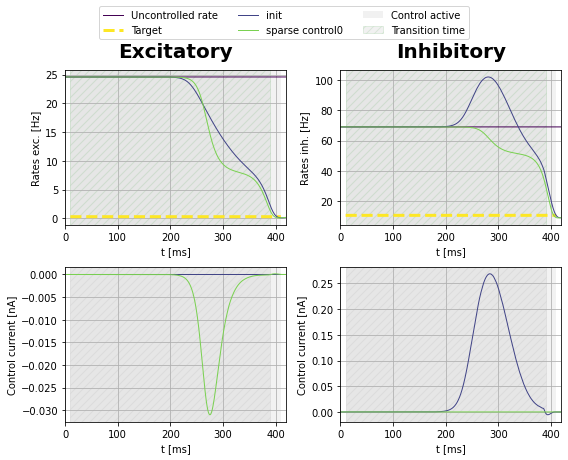

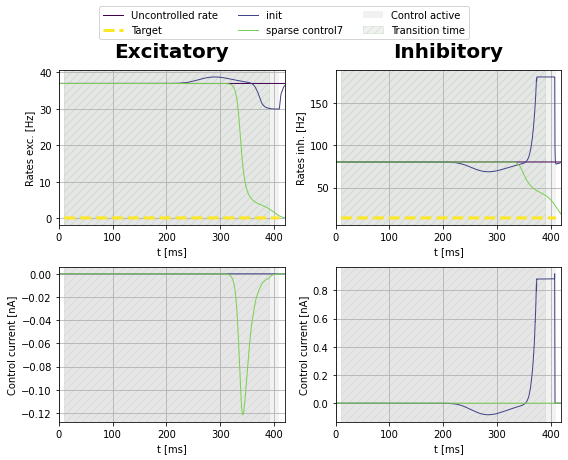

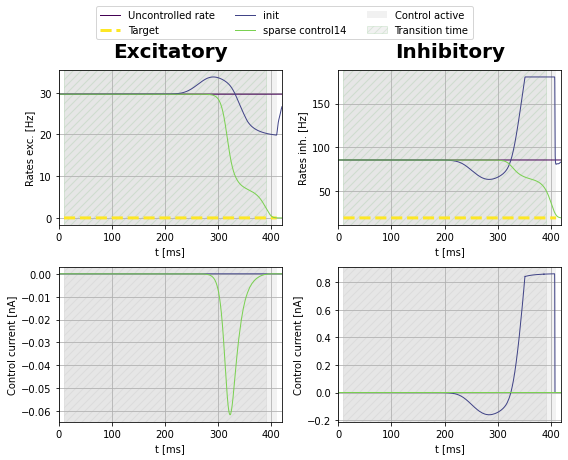

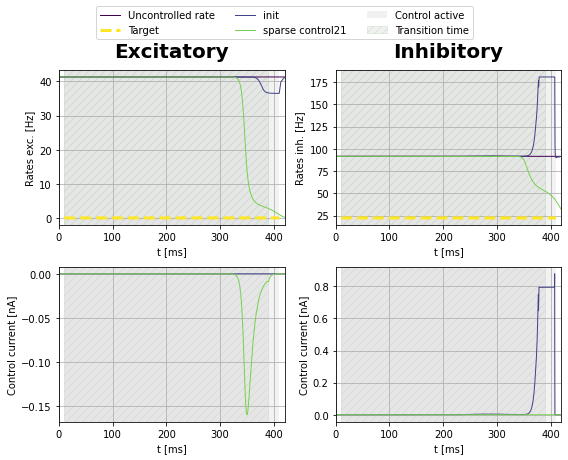

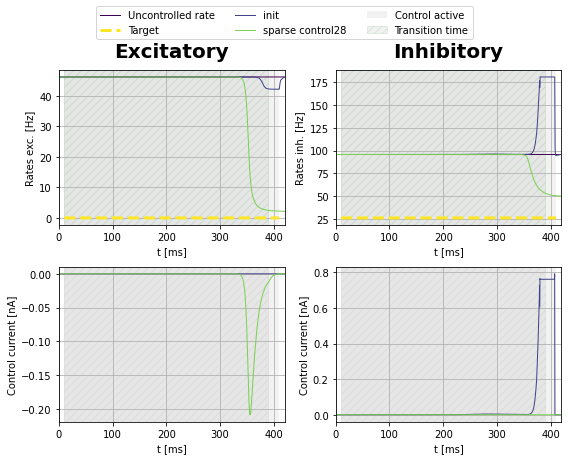

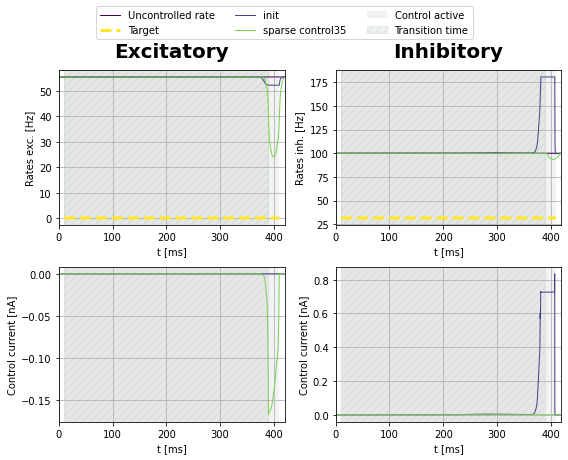

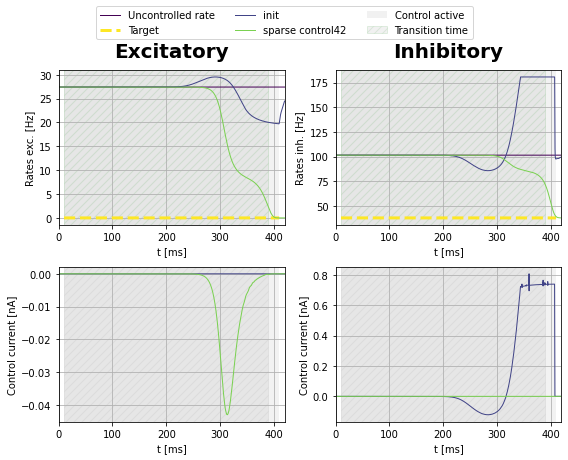

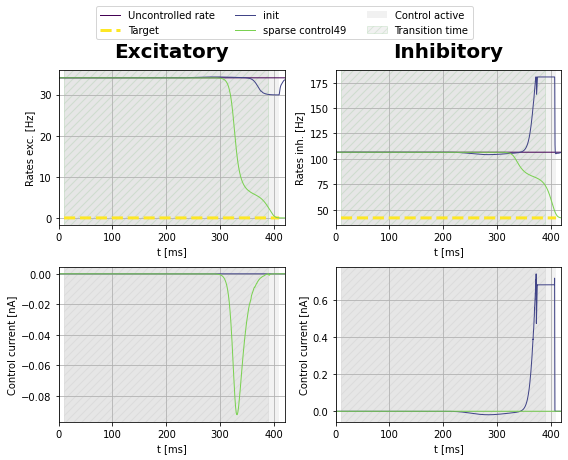

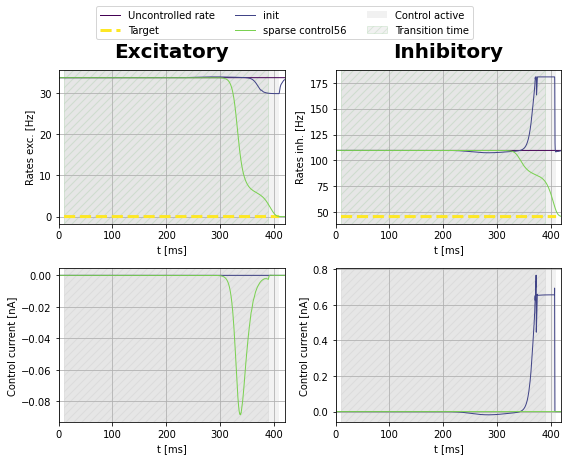

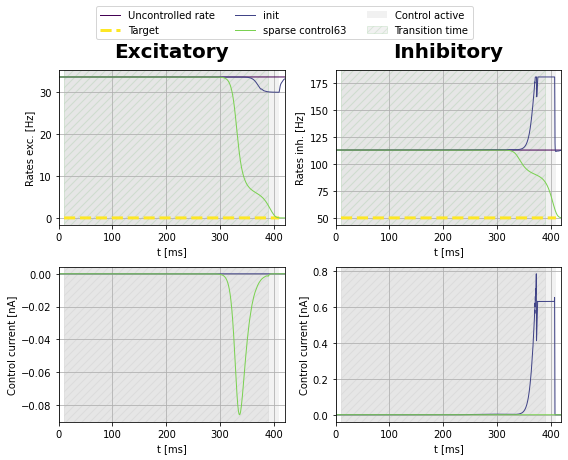

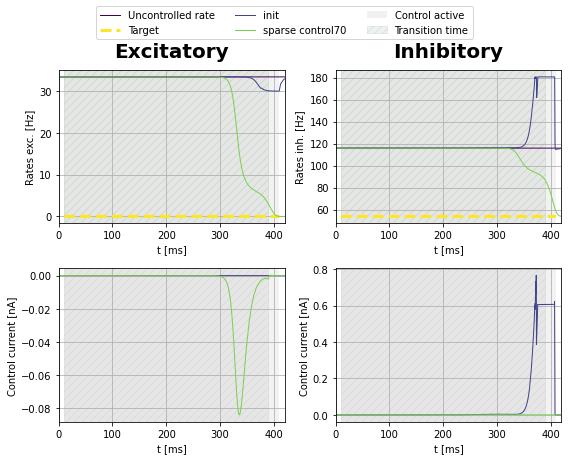

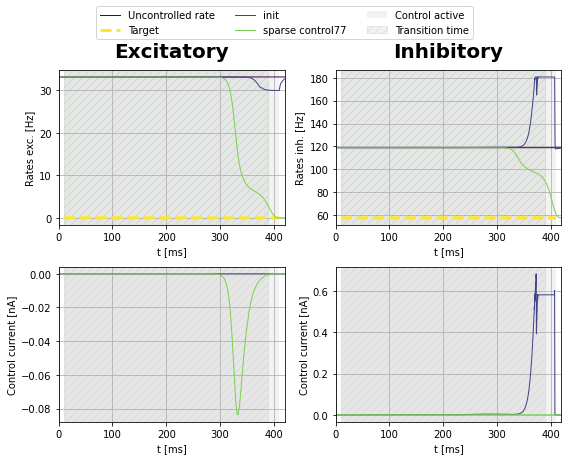

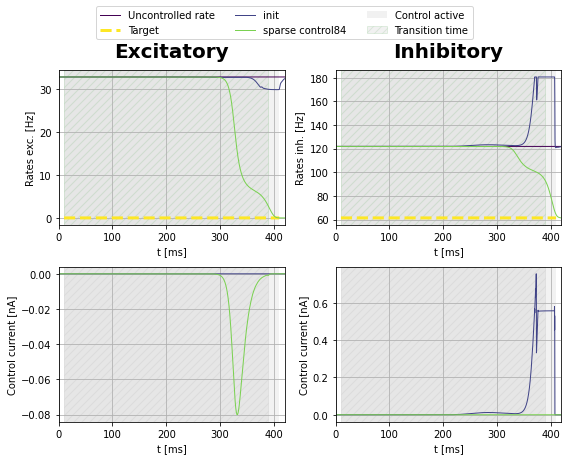

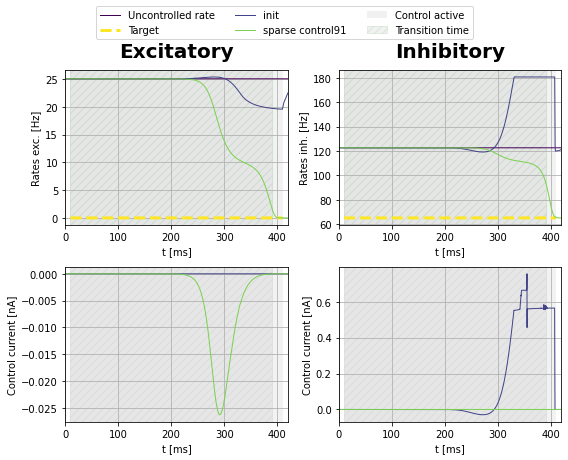

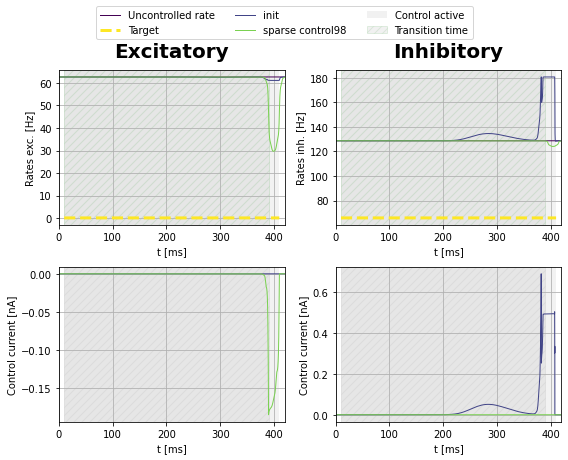

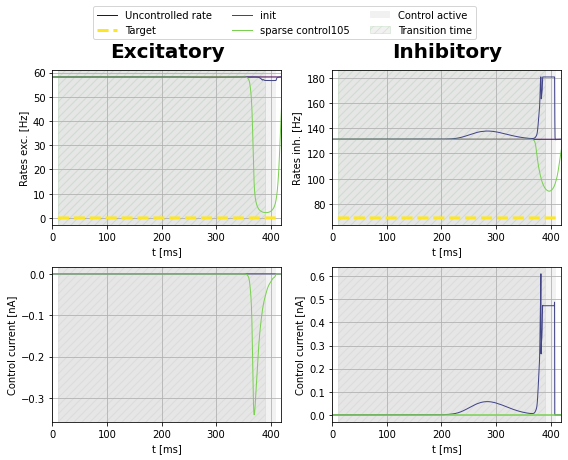

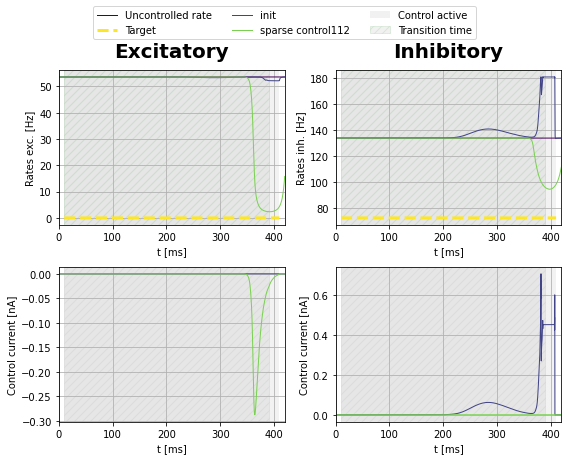

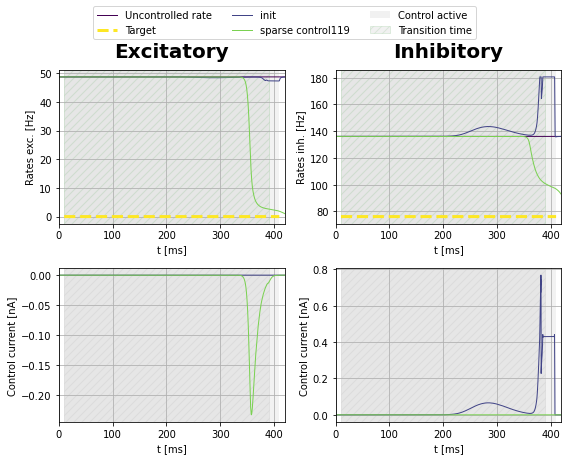

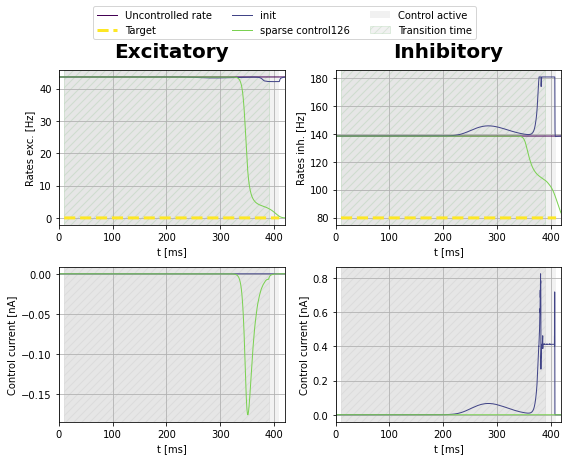

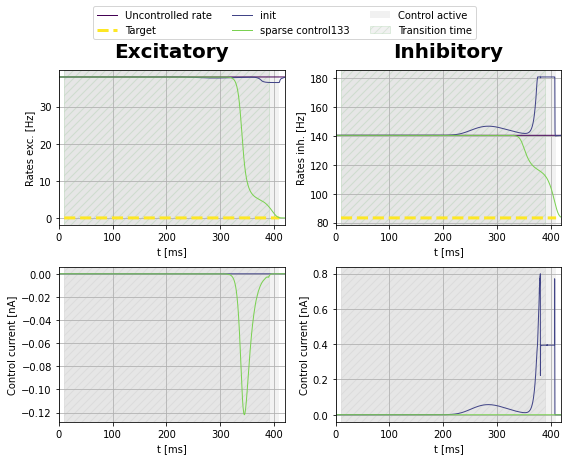

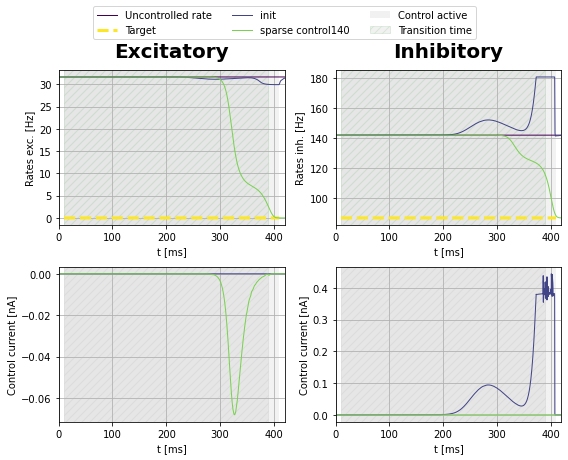

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6934.701080549736
set cost params:  1.0 0.0 6934.701080549736
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.5511421855
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.551137693159
RUN  2 , total integrated cost =  5901.551137691148
RUN  3 , total integrated cost =  5901.5511376911445
RUN  4 , total integrated cost =  5901.551137691143
RUN  5 , total integrated cost =  5901.551137691142
RUN  6 , total integrated cost =  5901.551137691141
RUN  7 , total integrated cost =  5901.55113769114


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5901.55113769114
Control only changes marginally.
RUN  8 , total integrated cost =  5901.55113769114
Improved over  8  iterations in  2.981471188366413  seconds by  7.615557251483551e-08  percent.
Problem in initial value trasfer:  Vmean_exc -64.73756849129613 -64.73526612020515
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  5679.865494174628
set cost params:  1.0 0.0 5679.865494174628
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13554.525172733061
Gradient descend method:  None
RUN  1 , total integrated cost =  13554.523945903928
RUN  2 , total integrated cost =  13554.523945400679
RUN  3 , total integrated cost =  13554.523945390752
RUN  4 , total integrated cost =  13554.52394539049
RUN  5 , total integrated cost =  13554.523945390483
RUN  6 , total integrated cost =  13554.523945390478


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  13554.523945390478
Control only changes marginally.
RUN  7 , total integrated cost =  13554.523945390478
Improved over  7  iterations in  2.7341740746051073  seconds by  9.054854871237694e-06  percent.
Problem in initial value trasfer:  Vmean_exc -61.127434200083194 -61.1470755932282
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  6324.96559970244
set cost params:  1.0 0.0 6324.96559970244
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8794.738642991253
Gradient descend method:  None
RUN  1 , total integrated cost =  8794.738603866681
RUN  2 , total integrated cost =  8794.738603800815
RUN  3 , total integrated cost =  8794.738603800804
RUN  4 , total integrated cost =  8794.738603800803
RUN  5 , total integrated cost =  8794.7386038008


...

RUN  5 , total integrated cost =  39213.95484628303
Control only changes marginally.
RUN  5 , total integrated cost =  39213.95484628303
Improved over  5  iterations in  2.060145614668727  seconds by  1.2398485864650866e-06  percent.
Problem in initial value trasfer:  Vmean_exc -56.70051791227224 -56.70044128152303
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 69
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [T

ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  39214.026290797556
Control only changes marginally.
RUN  6 , total integrated cost =  39214.026290797556
Improved over  6  iterations in  2.373415185138583  seconds by  0.000136958254813635  percent.
Problem in initial value trasfer:  Vmean_exc -56.70038325263783 -56.7003209100991
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 70
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [Tr

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  39214.125377267
Control only changes marginally.
RUN  1 , total integrated cost =  39214.125377267
Improved over  1  iterations in  0.4993489980697632  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70038325263783 -56.7003209100991
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 71
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.9994881671948528
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9218985190806833
RUN  2 , total integrated cost =  0.9200313619120977
RUN  3 , total integrated cost =  0.9191338596517998
RUN  4 , total integrated cost =  0.9188322318381374
RUN  5 , total integrated cost =  0.918490584646111
RUN  6 , total integrated cost =  0.9184627655994082
RUN  7 , total integrated cost =  0.9184627552387883
RUN  8 , total integrated cost =  0.9184627546169871
RUN  9 , total integrated cost =  0.9184627546169817
RUN  10 , total integrated cost =  0.9184627546169811


ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  0.9184627546169811
Control only changes marginally.
RUN  11 , total integrated cost =  0.9184627546169811
Improved over  11  iterations in  0.8140538223087788  seconds by  54.065106776524594  percent.
Problem in initial value trasfer:  Vmean_exc -62.799432508764866 -62.79945533687362
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.758152976031024
Gradient descend method:  None
RUN  1 , total integrated cost =  2.8306817411261087
RUN  2 , total integrated cost =  2.827091922949835
RUN  3 , total integrated cost =  2.824286442066195
RUN  4 , total integrated cost =  2.8240437469322766
RUN  5 , total integrated cost =  2.824043745445677
RUN  6 , total integrated cost =  2.8240437453478733
RUN  7 , total integrated cost =  2.824043745339612
RUN  8 , total integrated cost =  2.8240437453391256
RUN  9 , total integrated cost =  2.8240437453390745
RUN  

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  2.8240437453390648
Control only changes marginally.
RUN  13 , total integrated cost =  2.8240437453390648
Improved over  13  iterations in  0.8976189605891705  seconds by  90.8185522468148  percent.
Problem in initial value trasfer:  Vmean_exc -64.2771136575407 -64.2756969859348
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11.257665300858054
Gradient descend method:  None
RUN  1 , total integrated cost =  1.5299824524967005
RUN  2 , total integrated cost =  1.5288627863596267
RUN  3 , total integrated cost =  1.5288627357358178
RUN  4 , total integrated cost =  1.528862735735814


...

RUN  6 , total integrated cost =  5.060876691153068
Control only changes marginally.
RUN  6 , total integrated cost =  5.060876691153068
Improved over  6  iterations in  0.5611055474728346  seconds by  87.31005626266156  percent.
Problem in initial value trasfer:  Vmean_exc -69.06363793957527 -69.09592799507284
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.010881935962153
Gradient descend method:  None
RUN  1 , total integrated cost =  3.6409435667796974
RUN  2 , total integrated cost =  3.6389906382407693
RUN  3 , total integrated cost =  3.6389739960717087
RUN  4 , total integrated cost =  3.638973806072107
RUN  5 , total integrated cost =  3.6389737929001664
RUN  6 , total integrated cost =  3.638973791756402
RUN  7 , total integrated cost =  3.6389737916744
RUN  8 , total integrated cost =  3.638973791668182
RUN  9 , total integrated cost =  3.6389737916677443
RUN  10 , to

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  3.63897379166768
RUN  15 , total integrated cost =  3.638973791667679
RUN  16 , total integrated cost =  3.638973791667679
Control only changes marginally.
RUN  16 , total integrated cost =  3.638973791667679
Improved over  16  iterations in  1.0642568729817867  seconds by  87.87448566345834  percent.
Problem in initial value trasfer:  Vmean_exc -70.9226068939626 -70.9586674591993
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11.677133776141527
Gradient descend method:  None
RUN  1 , total integrated cost =  1.9201034112572788
RUN  2 , total integrated cost =  1.9196662698510567
RUN  3 , total integrated cost =  1.9196662685641264
RUN  4 , total integrated cost =  1.9196662685626606
RUN  5 , total integrated cost =  1.9196662685626305
RUN  6 , total integrated cost =  1.9196662685626076
RUN  7 , total integrated cost =  1.9196662685626016


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  1.9196662685626016
Control only changes marginally.
RUN  8 , total integrated cost =  1.9196662685626016
Improved over  8  iterations in  0.5688463002443314  seconds by  83.56046693166414  percent.
Problem in initial value trasfer:  Vmean_exc -73.16746338273371 -73.20527868036477


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9184627546169811
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9184627322291431
RUN  2 , total integrated cost =  0.9184627322291347
RUN  3 , total integrated cost =  0.9184627322291341
RUN  4 , total integrated cost =  0.918462732229134


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  0.918462732229134
Control only changes marginally.
RUN  5 , total integrated cost =  0.918462732229134
Improved over  5  iterations in  0.5120161157101393  seconds by  2.437534561749999e-06  percent.
Problem in initial value trasfer:  Vmean_exc -62.799536284326315 -62.79955213695094
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.8240437453390648
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.8240437453390648
Control only changes marginally.
RUN  1 , total integrated cost =  2.8240437453390648
Improved over  1  iterations in  0.1518038995563984  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.2771136575407 -64.2756969859348
-------  14 0.4250000000000001 0.4500000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.5288627357358138
Gradient descend method:  None


...

RUN  1 , total integrated cost =  5.060876691153068
Control only changes marginally.
RUN  1 , total integrated cost =  5.060876691153068
Improved over  1  iterations in  0.15479519963264465  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.06363793957527 -69.09592799507284
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.638973791667679
Gradient descend method:  None
RUN  1 , total integrated cost =  3.638973791667679
Control only changes marginally.
RUN  1 , total integrated cost =  3.638973791667679
Improved over  1  iterations in  0.15216339193284512  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.9226068939626 -70.9586674591993
-------  140 0.4500000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.91966626856260

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  1.9196662685625965
Control only changes marginally.
RUN  3 , total integrated cost =  1.9196662685625965
Improved over  3  iterations in  0.35417422465980053  seconds by  2.7000623958883807e-13  percent.
Problem in initial value trasfer:  Vmean_exc -73.16746336988297 -73.20527866757448
--------------- 21
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.918462732229134
Gradient descend method:  None
RUN  1 , total integrated cost =  0.918462732229134
Control only changes marginally.
RUN  1 , total integrat

ERROR:root:Problem in initial value trasfer


interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.9196662685625965
Gradient descend method:  None
RUN  1 , total integrated cost =  1.9196662685625965
Control only changes marginally.
RUN  1 , total integrated cost =  1.9196662685625965
Improved over  1  iterations in  0.1555381864309311  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.16746336988297 -73.20527866757448
--------------- 23
[[False, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.47500

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
